In [1]:
def sorting_coordinates(x,y):
    angles = np.arctan2(y, x)
    sort_idx = np.argsort(angles)
    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]

    return x_sorted,y_sorted

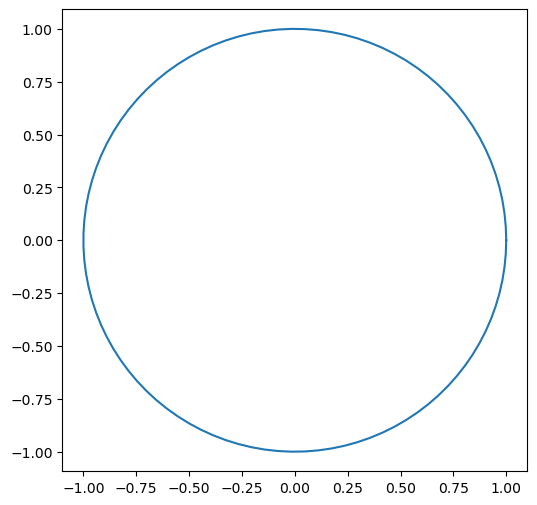

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N_points = 100

#  Main Circle in (x,y)
x_main_c = 0
y_main_c = 0

r_main   = 1
theta_main = np.linspace(0, 2*np.pi, N_points)

x_main = x_main_c +  r_main * np.cos(theta_main)
y_main = y_main_c +  r_main * np.sin(theta_main)

x_sorted_main,y_sorted_main = sorting_coordinates(x_main,y_main)

plt.figure(figsize=(6,6))
plt.plot(x_main, y_main)
plt.axis('equal')
plt.show()

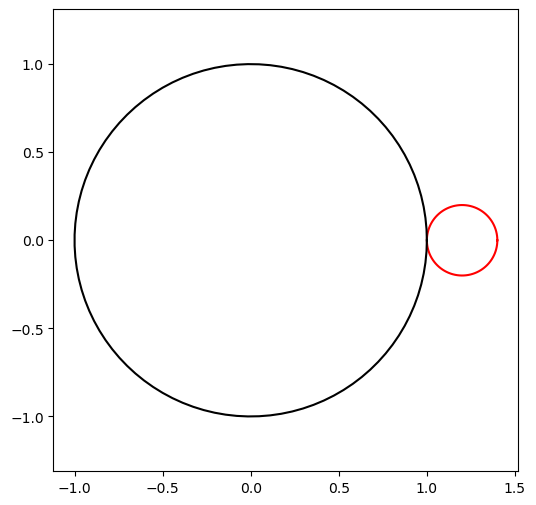

In [21]:
# Evaluate now the externals conferences where the forces will be applied:
# The centers will be distributed symmetrically around the center at a distance equal to radius main + radius externals
N_circles       = 1
N_points_ext    = 100

d_main_ext = 1.2 * r_main
r_ext      = d_main_ext - r_main 

theta_ext  = np.linspace(0, 2*np.pi, N_points_ext)

angle_ext_c = np.linspace(0,2*np.pi,N_circles)

x_ext_c = x_main_c + d_main_ext*np.cos(angle_ext_c)
y_ext_c = y_main_c + d_main_ext*np.sin(angle_ext_c)

x_ext = np.zeros((N_points_ext,N_circles))
y_ext = np.zeros((N_points_ext,N_circles))

for i in range(0,N_circles):
    x_ext[:,i] = x_ext_c[i] + r_ext * np.cos(theta_ext)
    y_ext[:,i] = y_ext_c[i] + r_ext * np.sin(theta_ext)

plt.figure(figsize=(6,6))
plt.plot(x_ext, y_ext , color='red')
plt.plot(x_main,y_main, color='black')
plt.axis('equal')
plt.show()

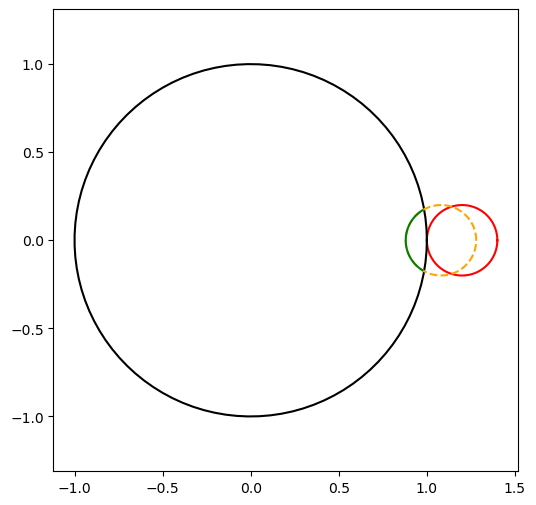

In [38]:
# Simulation of the interaction of a single sphere.
import math

s = 0.3 * (2*r_ext)
d_new = r_main - s 

x_new_c = x_ext_c - s*np.cos(angle_ext_c)
y_new_c = y_ext_c - s*np.sin(angle_ext_c)


x_new  = x_new_c +  r_ext*  np.cos(theta_main)
y_new  = y_new_c +  r_ext*  np.sin(theta_main)

theta_aperture = np.arccos( (r_main**2 - r_ext**2 - d_new**2)/ (2 * r_ext * d_new) )

theta_inner  = np.linspace(-theta_aperture, theta_aperture, N_points_ext)

x_inner = x_new_c + r_ext*  np.cos(np.pi-theta_inner)
y_inner = y_new_c + r_ext*  np.sin(np.pi-theta_inner)

plt.figure(figsize=(6,6))
plt.plot(x_ext, y_ext , color='red')
plt.plot(x_main,y_main, color='black')
plt.plot(x_new,y_new, linestyle='--',  color='orange')
plt.plot(x_inner,y_inner,color='green')
plt.axis('equal')
plt.show()


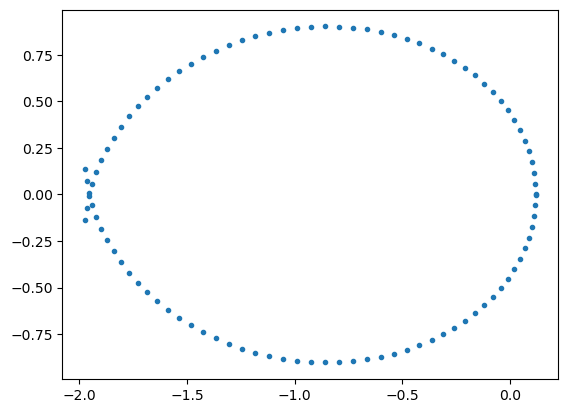

In [41]:
# Shape after interaction of the main circle:
x_sorted_main,y_sorted_main = sorting_coordinates(x_main,y_main)
x_sorted_arc,y_sorted_arc   = sorting_coordinates(x_inner,y_inner)

x_final = x_sorted_main - x_inner
y_final = y_sorted_main - y_inner

plt.plot(x_final,y_final,'.')
plt.show()